# Analiza Korelacji i Klasteryzacji Produktów

Ten notatnik analizuje korelację między 50 najpopularniejszymi (najczęściej sprzedawanymi) produktami na podstawie ich wzorców sprzedaży dziennej.

**Kluczowe kroki:**
1. Załaduj i przetwórz dane sprzedażowe
2. Wybierz 50 najpopularniejszych produktów wg całkowitej objętości sprzedaży
3. Oblicz macierz korelacji Pearsona na podstawie dziennej sprzedaży
4. Zastosuj klasteryzację hierarchiczną do identyfikacji grup produktów
5. Identyfikuj klastry z korelacją > 0,5 (umiarkowanie-silna)
6. Wizualizuj pełną macierz korelacji i projekcję UMAP
7. Szczegółowa analiza: wzorce korelacji 2 wybranych produktów

## 1. Importy i Zależności

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform, pdist
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Spróbuj zaimportować UMAP, zainstaluj jeśli niedostępny
try:
    from umap import UMAP
except ImportError:
    print("Instaluję UMAP...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn', '-q'])
    from umap import UMAP

# Ustaw styl wykresu
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Wszystkie importy udane (w tym UMAP)")

2026-03-17 14:49:41.432345: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 14:49:41.470065: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 14:49:41.470096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 14:49:41.471547: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 14:49:41.478028: I tensorflow/core/platform/cpu_feature_guar

✓ Wszystkie importy udane (w tym UMAP)


## 2. Załadowanie i Preprocessing Danych

**Ten sam pipeline co w dynamic_pricing.ipynb:**
- Usuń sprzedaż zerową
- Agreguj po dacie + produkt
- Dodaj cechy czasowe
- Wypełnij brakujące daty

In [2]:
# Załaduj dane surowe
df = pd.read_csv('sales.csv')
print(f"Rozmiar danych surowych: {df.shape}")
print(f"Kolumny: {list(df.columns)}")
df['date'] = pd.to_datetime(df['date'])

# Usuń sprzedaż zerową
print(f"\nUsuwanie rekordów ze sprzedażą zerową: {(df['sales'] == 0).sum()} wierszy")
df = df[df['sales'] > 0].copy()
print(f"Po usunięciu zer: {len(df)} wierszy")

# Agreguj po dacie i product_id
print(f"\nUnikalne sklepy: {df['store_id'].nunique()}")
print(f"Unikalne produkty PRZED agregacją: {df['product_id'].nunique()}")

df_agg = df.groupby(['date', 'product_id']).agg({
    'sales': 'sum',
    'price': 'mean',
    'revenue': 'sum',
    'stock': 'mean'
}).reset_index()

print(f"Po agregacji: {len(df_agg)} wierszy")

# Dodaj ilość sprzedaną
df_agg['qty_sold'] = df_agg['revenue'] / (df_agg['price'] + 1e-6)  # Unikaj dzielenia przez zero

print(f"✓ Dane zagregowane wg (date, product_id)")

Rozmiar danych surowych: (19454838, 13)
Kolumny: ['product_id', 'store_id', 'date', 'sales', 'revenue', 'stock', 'price', 'promo_type_1', 'promo_bin_1', 'promo_type_2', 'promo_bin_2', 'promo_discount_2', 'promo_discount_type_2']

Usuwanie rekordów ze sprzedażą zerową: 15074394 wierszy
Po usunięciu zer: 3189682 wierszy

Unikalne sklepy: 144
Unikalne produkty PRZED agregacją: 629
Po agregacji: 278484 wierszy
✓ Dane zagregowane wg (date, product_id)


## 3. Dodaj Cechy Czasowe

Dodaj dzień tygodnia, miesiąc, wzorce sezonowości i trend.

In [3]:
print("Dodawanie cech czasowych...")

df_agg['day_of_week'] = df_agg['date'].dt.dayofweek
df_agg['month'] = df_agg['date'].dt.month
df_agg['quarter'] = df_agg['date'].dt.quarter
df_agg['day_of_year'] = df_agg['date'].dt.dayofyear
df_agg['week_of_year'] = df_agg['date'].dt.isocalendar().week
df_agg['is_weekend'] = (df_agg['day_of_week'] >= 5).astype(int)
df_agg['is_monday'] = (df_agg['day_of_week'] == 0).astype(int)

# Trend
df_agg = df_agg.sort_values('date').reset_index(drop=True)
df_agg['trend'] = np.arange(len(df_agg))

# Średnie kroczące
df_agg['sales_ma_7d'] = df_agg.groupby('product_id')['sales'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)
df_agg['sales_ma_30d'] = df_agg.groupby('product_id')['sales'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)
df_agg['price_ma_30d'] = df_agg.groupby('product_id')['price'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)
df_agg['price_ratio'] = df_agg['price'] / (df_agg['price_ma_30d'] + 1e-6)

print(f"✓ Cechy czasowe dodane")
print(f"\nZakres dat: {df_agg['date'].min()} do {df_agg['date'].max()}")
print(f"Rozpiętość dni: {(df_agg['date'].max() - df_agg['date'].min()).days} dni")

Dodawanie cech czasowych...
✓ Cechy czasowe dodane

Zakres dat: 2017-01-02 00:00:00 do 2019-10-31 00:00:00
Rozpiętość dni: 1032 dni


## 4. Wybierz 50 Najpopularniejszych Produktów

Produkty uszeregowane wg całkowitej objętości sprzedaży (suma na wszystkie daty).

In [4]:
# Oblicz całkowitą sprzedaż na produkt
product_sales = df_agg.groupby('product_id')['sales'].sum().sort_values(ascending=False)

print(f"Całkowita liczba unikalnych produktów: {len(product_sales)}")
print(f"\nTop 10 produktów wg całkowitej sprzedaży:")
print(product_sales.head(10))

cumsum_pct = 100 * product_sales.cumsum() / product_sales.sum()
print(f"\n50 najpopularniejszych produktów stanowi {cumsum_pct.iloc[49]:.1f}% całkowitej sprzedaży")
print(f"100 najpopularniejszych produktów stanowi {cumsum_pct.iloc[99] if len(cumsum_pct) > 99 else 'N/A'}% całkowitej sprzedaży")

# Wybierz top 50 produktów
top_50_products = product_sales.head(50).index.tolist()
df_top50 = df_agg[df_agg['product_id'].isin(top_50_products)].copy()

print(f"\n✓ Wybrano {len(top_50_products)} produktów")
print(f"Rozmiar danych po filtrowaniu: {df_top50.shape}")
print(f"Pokrycie dat na produkt: min={df_top50.groupby('product_id').size().min()}, max={df_top50.groupby('product_id').size().max()}")

Całkowita liczba unikalnych produktów: 629

Top 10 produktów wg całkowitej sprzedaży:
product_id
P0103    881634.0
P0438    565348.0
P0364    277763.0
P0051    236744.0
P0388    215487.0
P0131    214924.0
P0569    192400.0
P0333    180100.0
P0590    163834.0
P0500    161805.0
Name: sales, dtype: float64

50 najpopularniejszych produktów stanowi 71.9% całkowitej sprzedaży
100 najpopularniejszych produktów stanowi 85.4398425212003% całkowitej sprzedaży

✓ Wybrano 50 produktów
Rozmiar danych po filtrowaniu: (45890, 19)
Pokrycie dat na produkt: min=273, max=1033


## 5. Utwórz Macierz Pivot

Transformuj w format macierzy: wiersze = daty, kolumny = product_id, wartości = dzienna sprzedaż.
Wypełnij brakujące daty i forward-fill sprzedaż.

**Uwaga:** Później (sekcja 5.5) użyjemy znormalizowanych 7-dniowych średnich kroczących do obliczenia korelacji, aby zmniejszyć szum dzienny i lepiej wychwycić wspólne wzorce popytu.

In [5]:
# Utwórz tabelę pivot: data x product_id
pivot_sales = df_top50.pivot_table(
    index='date',
    columns='product_id',
    values='sales',
    aggfunc='sum'
)

print(f"Rozmiar tabeli pivot: {pivot_sales.shape}")
print(f"Brakujące wartości: {pivot_sales.isna().sum().sum()}")

# Forward-fill brakujące wartości (produkt może nie mieć sprzedaży każdego dnia)
pivot_sales_filled = pivot_sales.fillna(method='ffill', limit=5).fillna(0)

print(f"Po forward-fill: {pivot_sales_filled.isna().sum().sum()} brakujących wartości")
print(f"\nStatystyki macierzy pivot:")
print(f"  Średnia dzienna sprzedaż na produkt: {pivot_sales_filled.mean().mean():.2f}")
print(f"  Odchylenie std: {pivot_sales_filled.std().mean():.2f}")
print(f"  Min: {pivot_sales_filled.min().min():.2f}")
print(f"  Max: {pivot_sales_filled.max().max():.2f}")

print(f"\n✓ Macierz pivot utworzona")

Rozmiar tabeli pivot: (1033, 50)
Brakujące wartości: 5760
Po forward-fill: 0 brakujących wartości

Statystyki macierzy pivot:
  Średnia dzienna sprzedaż na produkt: 111.61
  Odchylenie std: 116.95
  Min: 0.00
  Max: 43882.00

✓ Macierz pivot utworzona


## 5.5 Przygotowanie Znormalizowanych 7-Dniowych Średnich Kroczących

Aby lepiej wychwycić wspólne wzorce popytu (zmniejszyć szum dzienny), będziemy używać:
- **7-dniowe średnie kroczące** (sales_ma_7d) zamiast surowych wartości dziennych
- **Znormalizowanie** każdego produktu do zakresu 0-1 (MinMaxScaler) aby wyrównać różne skale sprzedaży
- To będzie bazą do obliczenia korelacji


In [6]:
# Utwórz pivot z 7-dniowymi średnimi kroczącymi
print("Tworzenie macierzy z 7-dniowymi średnimi kroczącymi...")
pivot_sales_ma7d = df_top50.pivot_table(
    index='date',
    columns='product_id',
    values='sales_ma_7d',
    aggfunc='mean'
)

print(f"Rozmiar pivot (sales_ma_7d): {pivot_sales_ma7d.shape}")
print(f"Brakujące wartości: {pivot_sales_ma7d.isna().sum().sum()}")

# Wypełnij brakujące wartości
pivot_sales_ma7d_filled = pivot_sales_ma7d.fillna(method='ffill', limit=5).fillna(0)

print(f"Po forward-fill: {pivot_sales_ma7d_filled.isna().sum().sum()} brakujących wartości")

# Normalizuj każdy produkt do zakresu 0-1 (MinMaxScaler)
print("\nNormalizowanie każdego produktu (MinMax: 0-1)...")
scaler = MinMaxScaler(feature_range=(0, 1))
pivot_sales_normalized = pd.DataFrame(
    scaler.fit_transform(pivot_sales_ma7d_filled),
    index=pivot_sales_ma7d_filled.index,
    columns=pivot_sales_ma7d_filled.columns
)

print(f"Rozmiar znormalizowanej macierzy: {pivot_sales_normalized.shape}")
print(f"\nStatystyki znormalizowanej macierzy:")
print(f"  Średnia na produkt: {pivot_sales_normalized.mean().mean():.3f}")
print(f"  Min na produkt: {pivot_sales_normalized.min().min():.3f}")
print(f"  Max na produkt: {pivot_sales_normalized.max().max():.3f}")

print(f"\n✓ Znormalizowane 7-dniowe średnie kroczące przygotowane")

Tworzenie macierzy z 7-dniowymi średnimi kroczącymi...
Rozmiar pivot (sales_ma_7d): (1033, 50)
Brakujące wartości: 5760
Po forward-fill: 0 brakujących wartości

Normalizowanie każdego produktu (MinMax: 0-1)...
Rozmiar znormalizowanej macierzy: (1033, 50)

Statystyki znormalizowanej macierzy:
  Średnia na produkt: 0.277
  Min na produkt: 0.000
  Max na produkt: 1.000

✓ Znormalizowane 7-dniowe średnie kroczące przygotowane


## 6. Oblicz Macierz Korelacji Pearsona

Korelacja między 50 produktami na podstawie **znormalizowanych 7-dniowych średnich kroczących** (sales_ma_7d).

**Metodologia (Opcja 3):**
- Używamy `sales_ma_7d` zamiast surowych wartości dziennych → zmniejsza szum dzienny
- Normalizujemy każdy produkt do zakresu 0-1 (MinMaxScaler) → wyrównuje różne skale sprzedaży
- Wynik: większa liczba produktów ze znaczącą korelacją (>0.5), które rzeczywiście odzwierciedlają wspólne wzorce popytu

In [7]:
# Oblicz macierz korelacji Pearsona na znormalizowanych 7-dniowych średnich
print("Obliczanie macierzy korelacji Pearsona na znormalizowanych sales_ma_7d...")
correlation_matrix = pivot_sales_normalized.corr(method='pearson')

print(f"Rozmiar macierzy korelacji: {correlation_matrix.shape}")
print(f"\nStatystyki macierzy korelacji:")
print(f"  Diagonala (powinna być ≈ 1.0): min={correlation_matrix.values.diagonal().min():.4f}, max={correlation_matrix.values.diagonal().max():.4f}")

# Wyodrębnij górny trójkąt (nienadmiarowe korelacje)
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
upper_values = upper_triangle.values[np.triu_indices_from(upper_triangle.values, k=1)]

print(f"\nWszystkie korelacje pairwise (górny trójkąt):")
print(f"  Średnia: {upper_values.mean():.4f}")
print(f"  Std: {upper_values.std():.4f}")
print(f"  Min: {upper_values.min():.4f}")
print(f"  Max: {upper_values.max():.4f}")
print(f"  Mediana: {np.median(upper_values):.4f}")

# Rozkład korelacji
corr_thresholds = [-0.5, -0.2, 0.0, 0.2, 0.5, 0.7]
for threshold in corr_thresholds:
    count = (upper_values >= threshold).sum()
    pct = 100 * count / len(upper_values)
    print(f"  Korelacje >= {threshold:+.1f}: {count:4d} ({pct:5.1f}%)")

print(f"\n✓ Macierz korelacji obliczona (na znormalizowanych sales_ma_7d)")

Obliczanie macierzy korelacji Pearsona na znormalizowanych sales_ma_7d...
Rozmiar macierzy korelacji: (50, 50)

Statystyki macierzy korelacji:
  Diagonala (powinna być ≈ 1.0): min=1.0000, max=1.0000

Wszystkie korelacje pairwise (górny trójkąt):
  Średnia: 0.0230
  Std: 0.2673
  Min: -0.8253
  Max: 0.8469
  Mediana: 0.0085
  Korelacje >= -0.5: 1189 ( 97.1%)
  Korelacje >= -0.2: 1027 ( 83.8%)
  Korelacje >= +0.0:  630 ( 51.4%)
  Korelacje >= +0.2:  273 ( 22.3%)
  Korelacje >= +0.5:   60 (  4.9%)
  Korelacje >= +0.7:   12 (  1.0%)

✓ Macierz korelacji obliczona (na znormalizowanych sales_ma_7d)


## 7. Klasteryzacja Hierarchiczna

Zastosuj klasteryzację hierarchiczną używając Ward linkage na macierzy odległości korelacji (1 - korelacja).

In [8]:
# Konwertuj korelację na odległość
distance_matrix = 1 - correlation_matrix.values
np.fill_diagonal(distance_matrix, 0)  # Diagonala powinna być 0 (odległość od siebie)

# Wykonaj klasteryzację hierarchiczną
condensed_distances = squareform(distance_matrix, checks=False)
Z = linkage(condensed_distances, method='ward')

print(f"Rozmiar macierzy linkage: {Z.shape}")
print(f"Macierz linkage zawiera {Z.shape[0]} połączeń")
print(f"\nPierwszych 10 połączeń (klaster1, klaster2, odległość, liczba członków):")
print(Z[:10])

print(f"\n✓ Klasteryzacja hierarchiczna ukończona (Ward linkage)")

Rozmiar macierzy linkage: (49, 4)
Macierz linkage zawiera 49 połączeń

Pierwszych 10 połączeń (klaster1, klaster2, odległość, liczba członków):
[[34.         45.          0.15310956  2.        ]
 [37.         39.          0.21131775  2.        ]
 [32.         49.          0.21806715  2.        ]
 [10.         51.          0.24273572  3.        ]
 [29.         50.          0.25563823  3.        ]
 [ 0.          3.          0.27999978  2.        ]
 [25.         46.          0.28335085  2.        ]
 [ 4.         21.          0.34012365  2.        ]
 [31.         40.          0.3546521   2.        ]
 [27.         57.          0.3656762   3.        ]]

✓ Klasteryzacja hierarchiczna ukończona (Ward linkage)


## 8. Identyfikuj Klastry Produktów

Wyodrębnij przypisania klastrów używając progu odległości i identyfikuj klastry o wysokiej korelacji (średnia korelacja > 0.5).

In [9]:
# Określ liczbę klastrów używając progu odległości
max_d = Z[-10, 2]
print(f"Używanie progu odległości: {max_d:.4f}")
print(f"(Ostatnich 10 odległości połączenia: {Z[-10:, 2]})")

# Spróbuj różne progi, aby znaleźć rozsądną liczbę klastrów
thresholds = np.percentile(Z[:, 2], [80, 85, 90, 95])
print(f"\nprógi:")
for t in thresholds:
    clusters = fcluster(Z, t, criterion='distance')
    n_clusters = len(np.unique(clusters))
    print(f"  Próg {t:.4f}: {n_clusters} klastrów")

threshold = np.percentile(Z[:, 2], 85)
cluster_labels = fcluster(Z, threshold, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"\nUżywanie progu {threshold:.4f} → {n_clusters} klastrów")

# Utwórz dataframe przypisania klastrów
cluster_df = pd.DataFrame({
    'product_id': correlation_matrix.columns,
    'cluster': cluster_labels
}).sort_values('cluster')

print(f"\nRozmiary klastrów:")
cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
print(cluster_sizes)

cluster_df

Używanie progu odległości: 0.9570
(Ostatnich 10 odległości połączenia: [0.95701126 1.0087268  1.11260428 1.29495985 1.44296804 1.72374858
 1.84297211 1.95613611 2.40418488 3.60827313])

Eksplozpra prógi:
  Próg 0.9533: 11 klastrów
  Próg 1.0918: 9 klastrów
  Próg 1.4991: 6 klastrów
  Próg 1.9109: 4 klastrów

Używanie progu 1.0918 → 9 klastrów

Rozmiary klastrów:
cluster
1     8
2     3
3     6
4    10
5     7
6     6
7     4
8     2
9     4
Name: count, dtype: int64


,product_id,cluster
0,P0017,1
3,P0079,1
5,P0103,1
11,P0140,1
49,P0726,1
44,P0642,1
33,P0458,1
32,P0438,1
13,P0185,2
2,P0051,2


## 9. Analizuj Jakość Klastrów

Dla każdego klastra oblicz średnią korelację wewnętrzną, aby identyfikować grupy o wysokiej korelacji (średnia korelacja > 0.5).

In [10]:
# Analizuj jakość klastrów
cluster_quality = []

for cluster_id in sorted(cluster_df['cluster'].unique()):
    products_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['product_id'].values
    
    if len(products_in_cluster) > 1:
        # Wyodrębnij podmacierz korelacji w klastrze
        cluster_corr = correlation_matrix.loc[products_in_cluster, products_in_cluster]
        
        # Wyodrębnij górny trójkąt
        upper_tri = cluster_corr.where(
            np.triu(np.ones(cluster_corr.shape), k=1).astype(bool)
        ).values
        upper_tri_values = upper_tri[np.triu_indices_from(upper_tri, k=1)]
        
        mean_corr = upper_tri_values.mean() if len(upper_tri_values) > 0 else np.nan
        std_corr = upper_tri_values.std() if len(upper_tri_values) > 0 else np.nan
        min_corr = upper_tri_values.min() if len(upper_tri_values) > 0 else np.nan
        max_corr = upper_tri_values.max() if len(upper_tri_values) > 0 else np.nan
    else:
        mean_corr = std_corr = min_corr = max_corr = np.nan
    
    cluster_quality.append({
        'cluster_id': cluster_id,
        'size': len(products_in_cluster),
        'mean_corr': mean_corr,
        'std_corr': std_corr,
        'min_corr': min_corr,
        'max_corr': max_corr,
        'is_highly_correlated': mean_corr > 0.5 if not np.isnan(mean_corr) else False
    })

cluster_quality_df = pd.DataFrame(cluster_quality).sort_values('mean_corr', ascending=False, na_position='last')

print("Analiza Jakości Klastrów (posortowane wg średniej korelacji wewnętrznej):")
print(cluster_quality_df.to_string(index=False))

# Policz klastry o wysokiej korelacji
highly_corr_clusters = cluster_quality_df[cluster_quality_df['is_highly_correlated'] == True]
print(f"\n{len(highly_corr_clusters)} klastrów ze średnią korelacją > 0.5")
if len(highly_corr_clusters) > 0:
    print("\nSzczegóły klastrów o wysokiej korelacji:")
    for idx, row in highly_corr_clusters.iterrows():
        cluster_id = row['cluster_id']
        products = cluster_df[cluster_df['cluster'] == cluster_id]['product_id'].values
        print(f"  Klaster {cluster_id}: {row['size']} produktów, mean_corr={row['mean_corr']:.3f}")
        print(f"    Produkty: {products}")

Analiza Jakości Klastrów (posortowane wg średniej korelacji wewnętrznej):
 cluster_id  size  mean_corr  std_corr  min_corr  max_corr  is_highly_correlated
          5     7   0.534729  0.178345  0.162830  0.788682                  True
          4    10   0.469572  0.168712  0.054847  0.846890                 False
          6     6   0.451630  0.127376  0.222806  0.716649                 False
          1     8   0.429098  0.209760  0.079146  0.781933                 False
          2     3   0.367846  0.095661  0.232562  0.436124                 False
          3     6   0.367298  0.110710  0.196365  0.519222                 False
          7     4   0.230296  0.161409 -0.013023  0.470282                 False
          8     2   0.200762  0.000000  0.200762  0.200762                 False
          9     4   0.101313  0.107983  0.001986  0.275780                 False

1 klastrów ze średnią korelacją > 0.5

Szczegóły klastrów o wysokiej korelacji:
  Klaster 5: 7 produktów, mean_corr

## 10. Wizualizacja 1: Projekcja 2D UMAP

Wizualizacja rozrzutu 2D przestrzeni korelacji produktów.
- **Zbliżenie**: Bliskie punkty = Bardziej skorelowane produkty
- **Kolor**: Przynależność do klastra
- **Rozmiar**: Całkowita objętość sprzedaży (większy = bardziej popularny)

**Bazuje na:** Znormalizowanych 7-dniowych średnich kroczących (sales_ma_7d)

Obliczanie osadzenia UMAP ze zdalów korelacji...
✓ Osadzenie UMAP obliczone
  Rozmiar osadzenia: (50, 2)


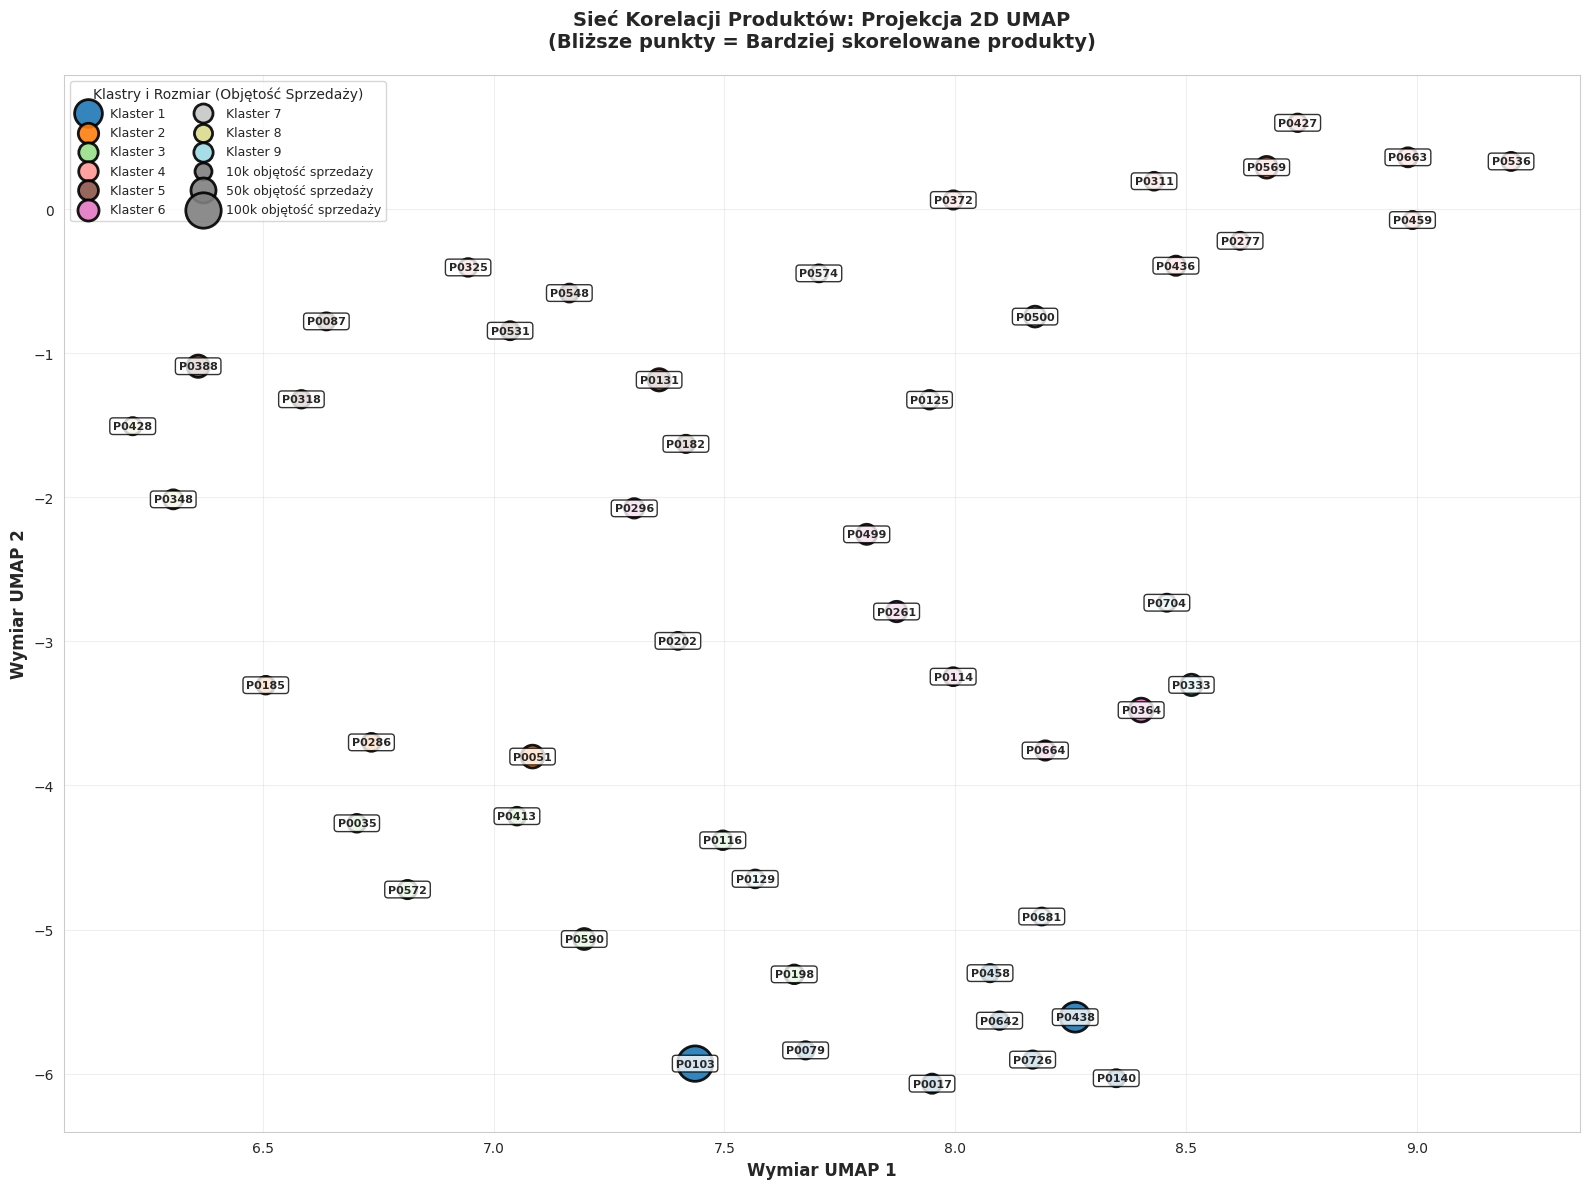

✓ Projekcja 2D UMAP zapisana jako 'umap_correlation_space.png'


In [11]:
# Oblicz osadzenie UMAP z macierzy odległości korelacji
print("Obliczanie osadzenia UMAP ze zdalów korelacji...")
distance_matrix_for_umap = 1 - correlation_matrix.values
np.fill_diagonal(distance_matrix_for_umap, 0)

# UMAP z odległością korelacji
umap_model = UMAP(n_components=2, metric='precomputed', n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = umap_model.fit_transform(distance_matrix_for_umap)

print(f"✓ Osadzenie UMAP obliczone")
print(f"  Rozmiar osadzenia: {umap_embedding.shape}")

# Uzyskaj sprzedaż produktu do skalowania rozmiaru
product_sizes = df_top50.groupby('product_id')['sales'].sum().reindex(correlation_matrix.columns, fill_value=0).values
product_sizes_normalized = 150 + 500 * (product_sizes - product_sizes.min()) / (product_sizes.max() - product_sizes.min() + 1e-6)

# Utwórz wykres rozrzutu 2D
fig, ax = plt.subplots(figsize=(16, 12))

# Uzyskaj unikalne klastry i utwórz paletę kolorów
unique_clusters = np.unique(cluster_labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
cluster_colors = {c: colors[i] for i, c in enumerate(unique_clusters)}

# Rysuj każdy klaster z własnym kolorem
for cluster_id in sorted(unique_clusters):
    mask = cluster_labels == cluster_id
    ax.scatter(umap_embedding[mask, 0], umap_embedding[mask, 1],
              c=[cluster_colors[cluster_id]], s=product_sizes_normalized[mask],
              alpha=0.9, edgecolors='black', linewidth=2,
              label=f'Klaster {cluster_id}')

# Dodaj etykiety produktów
for idx, product_id in enumerate(correlation_matrix.columns):
    ax.annotate(str(product_id), 
               (umap_embedding[idx, 0], umap_embedding[idx, 1]),
               fontsize=8, ha='center', va='center', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black', linewidth=1))

ax.set_xlabel('Wymiar UMAP 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Wymiar UMAP 2', fontsize=12, fontweight='bold')
ax.set_title('Sieć Korelacji Produktów: Projekcja 2D UMAP\n(Bliższe punkty = Bardziej skorelowane produkty)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, ncol=2, title='Klastry', title_fontsize=10)

# Dodaj legendę rozmiaru
for size_label, size_val in [(10, 150), (50, 325), (100, 650)]:
    ax.scatter([], [], s=size_val, c='gray', alpha=0.9, edgecolors='black', linewidth=2,
              label=f'{size_label}k objętość sprzedaży')
ax.legend(loc='best', fontsize=9, ncol=2, title='Klastry i Rozmiar (Objętość Sprzedaży)', title_fontsize=10)

plt.tight_layout()
plt.savefig('umap_correlation_space.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Projekcja 2D UMAP zapisana jako 'umap_correlation_space.png'")

## 11. Wizualizacja 2: Pełna Mapa Ciepła Korelacji

Macierz korelacji 50×50 (posortowana wg klasteryzacji hierarchicznej).

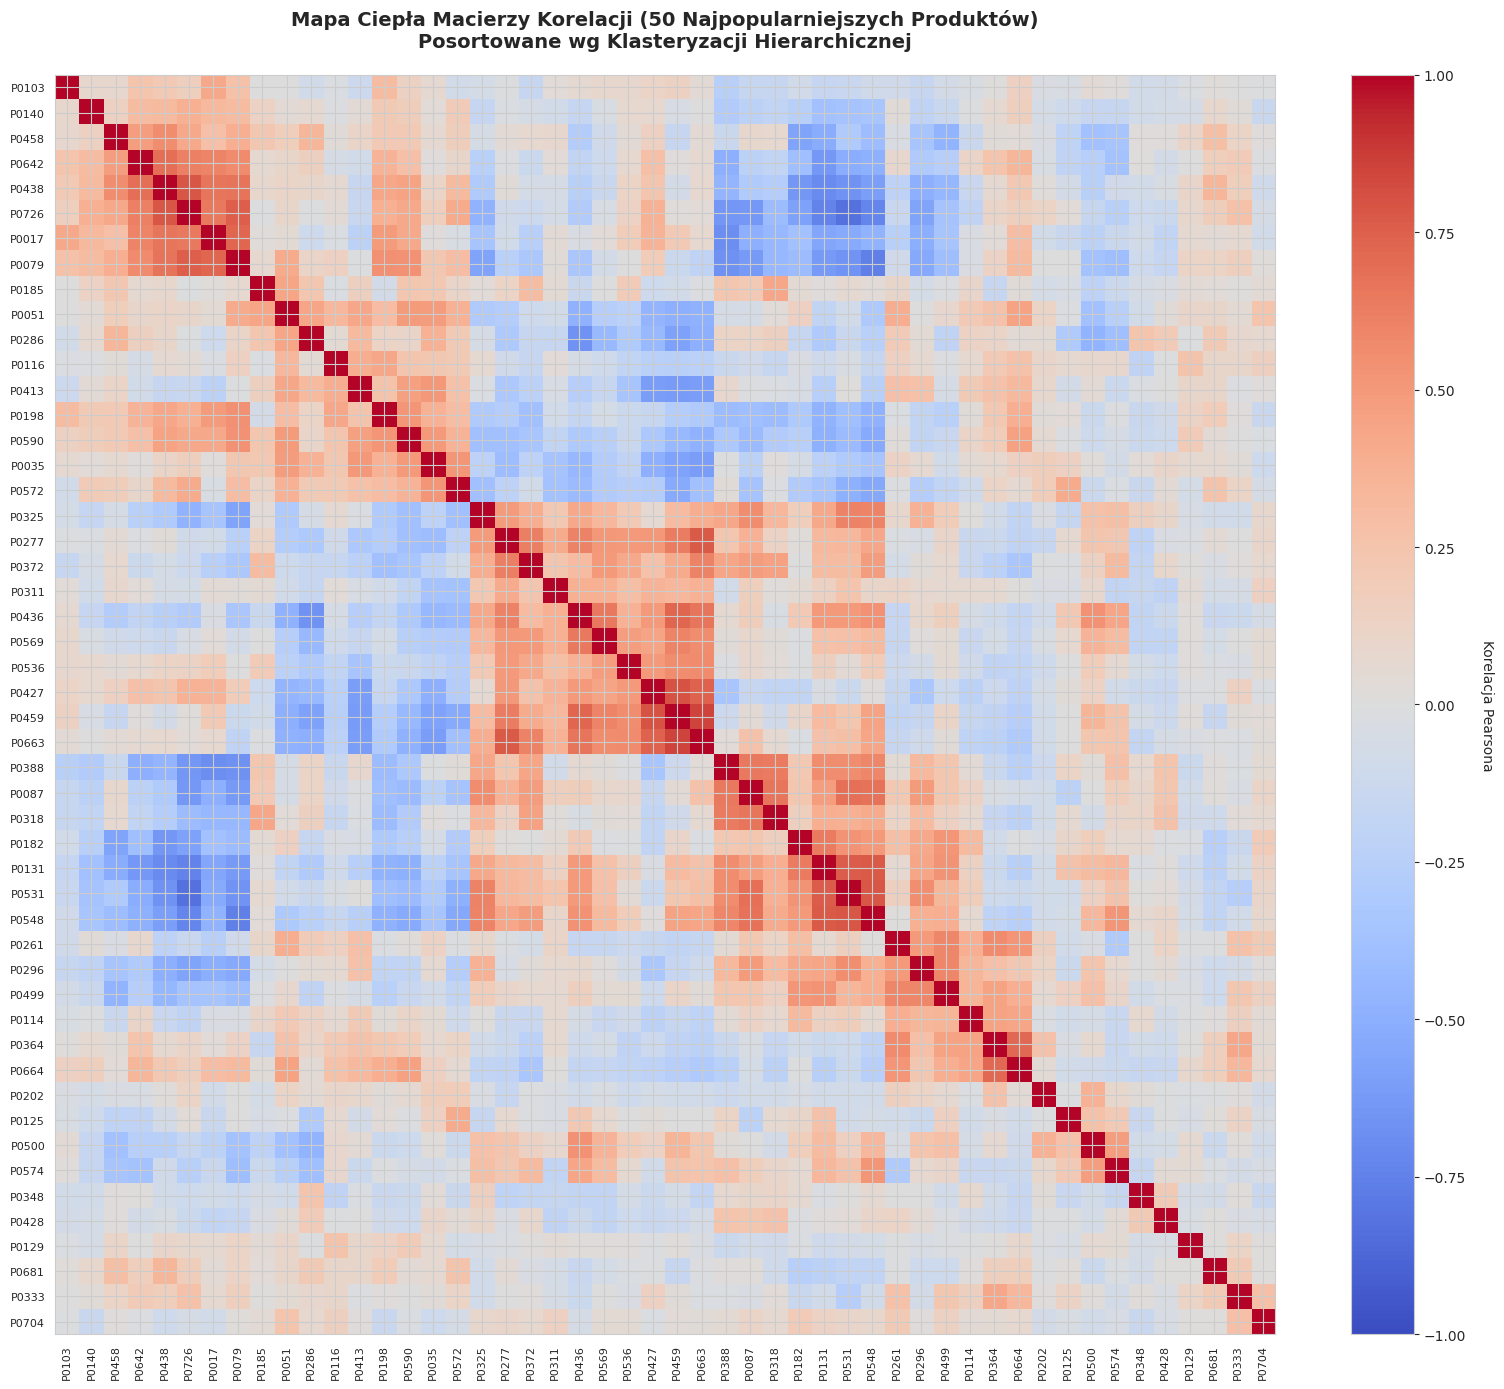

✓ Mapa ciepła korelacji zapisana jako 'correlation_heatmap.png'


In [12]:
# Zmień kolejność produktów wg porządku dendrogram
from scipy.cluster.hierarchy import dendrogram

dendro = dendrogram(Z, labels=correlation_matrix.columns.astype(str), no_plot=True)
dendrogram_order_labels = dendro['ivl']  # Etykiety w porządku dendrogram

# Utwórz mapowanie z etykiety na oryginalny indeks
label_to_index = {str(label): idx for idx, label in enumerate(correlation_matrix.columns)}
dendrogram_order = [label_to_index[label] for label in dendrogram_order_labels]

# Zmień kolejność macierzy korelacji
corr_ordered = correlation_matrix.iloc[dendrogram_order, dendrogram_order]

# Utwórz mapę ciepła
fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(corr_ordered.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Ustaw zaznaczenia i etykiety
ax.set_xticks(np.arange(len(corr_ordered)))
ax.set_yticks(np.arange(len(corr_ordered)))
ax.set_xticklabels(corr_ordered.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_ordered.columns, fontsize=8)

# Dodaj pasek kolorów
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Korelacja Pearsona', rotation=270, labelpad=20)

ax.set_title('Mapa Ciepła Macierzy Korelacji (50 Najpopularniejszych Produktów)\nPosortowane wg Klasteryzacji Hierarchicznej', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Mapa ciepła korelacji zapisana jako 'correlation_heatmap.png'")

## 12. Wizualizacja 3: Szczegółowa Analiza Korelacji Dwóch Produktów

Wybierz 2 produkty i pokaż:
- Macierz korelacji 2×2
- Nakładki szeregów czasowych
- Wykres rozrzutu współzmienności

Wybrane produkty do analizy szczegółowej:
  Produkt 1: P0388 (z klasstera 5)
  Produkt 2: P0333 (z klasstera 9)
  Korelacja: -0.0282


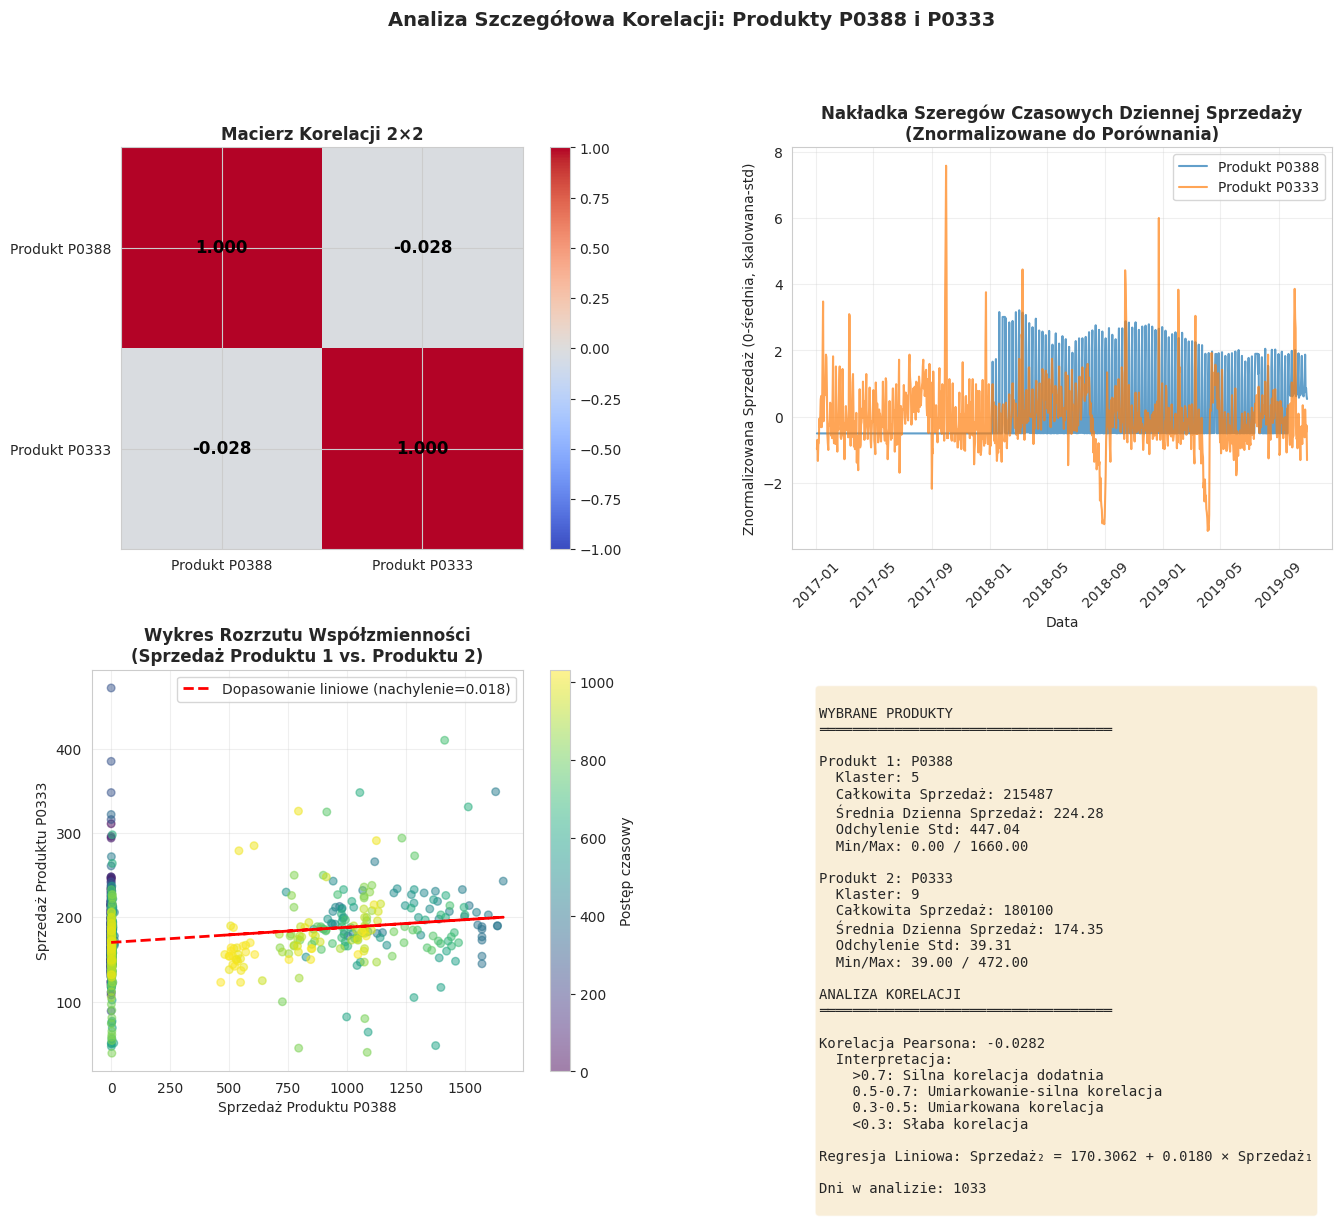

✓ Analiza dwóch produktów zapisana jako 'two_product_correlation_analysis.png'


In [13]:
# Wybierz 2 produkty do szczegółowej analizy
# Strategia: Wybierz jeden z dużego, wysoko skorelowanego klastra i jeden ze słabego klastra

# Znajdź produkty z najsilniejszego klastra (najwyższa średnia korelacja)
strongest_cluster_id = cluster_quality_df.iloc[0]['cluster_id']
products_strongest = cluster_df[cluster_df['cluster'] == strongest_cluster_id]['product_id'].values

# Znajdź produkty z najsłabszego klastra
weakest_cluster_id = cluster_quality_df.iloc[-1]['cluster_id']
products_weakest = cluster_df[cluster_df['cluster'] == weakest_cluster_id]['product_id'].values

# Wybierz 2 produkty: jeden z najsilniejszego, jeden ze słabszego (jeśli dostępne)
if len(products_strongest) > 0 and len(products_weakest) > 0:
    product1 = products_strongest[0]
    product2 = products_weakest[0]
else:
    # Fallback: wybierz top 2 najbardziej skorelowane produkty
    max_corr_idx = np.unravel_index(np.argmax(correlation_matrix.values - np.eye(len(correlation_matrix))), 
                                     correlation_matrix.shape)
    product1 = correlation_matrix.columns[max_corr_idx[0]]
    product2 = correlation_matrix.columns[max_corr_idx[1]]

print(f"Wybrane produkty do analizy szczegółowej:")
print(f"  Produkt 1: {product1} (z klasstera {strongest_cluster_id})")
print(f"  Produkt 2: {product2} (z klasstera {weakest_cluster_id})")
print(f"  Korelacja: {correlation_matrix.loc[product1, product2]:.4f}")

# Wyodrębnij szeregi czasowe
ts1 = pivot_sales_filled[product1]
ts2 = pivot_sales_filled[product2]

# Znormalizuj do nakładki
ts1_norm = (ts1 - ts1.mean()) / ts1.std()
ts2_norm = (ts2 - ts2.mean()) / ts2.std()

# Utwórz podwykresy
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# --- Wykres 1: Macierz Korelacji (2x2) ---
ax1 = fig.add_subplot(gs[0, 0])
corr_2x2 = correlation_matrix.loc[[product1, product2], [product1, product2]]
im1 = ax1.imshow(corr_2x2.values, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels([f'Produkt {product1}', f'Produkt {product2}'])
ax1.set_yticklabels([f'Produkt {product1}', f'Produkt {product2}'])
ax1.set_title('Macierz Korelacji 2×2', fontweight='bold')
for i in range(2):
    for j in range(2):
        text = ax1.text(j, i, f'{corr_2x2.values[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1)

# --- Wykres 2: Nakładka Szeregów Czasowych ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ts1.index, ts1_norm, label=f'Produkt {product1}', alpha=0.7, linewidth=1.5)
ax2.plot(ts2.index, ts2_norm, label=f'Produkt {product2}', alpha=0.7, linewidth=1.5)
ax2.set_xlabel('Data')
ax2.set_ylabel('Znormalizowana Sprzedaż (0-średnia, skalowana-std)')
ax2.set_title('Nakładka Szeregów Czasowych Dziennej Sprzedaży\n(Znormalizowane do Porównania)', fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# --- Wykres 3: Wykres Rozrzutu (Współzmienność) ---
ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(ts1, ts2, alpha=0.5, s=30, c=range(len(ts1)), cmap='viridis')
z = np.polyfit(ts1, ts2, 1)
p = np.poly1d(z)
ax3.plot(ts1, p(ts1), "r--", linewidth=2, label=f'Dopasowanie liniowe (nachylenie={z[0]:.3f})')
ax3.set_xlabel(f'Sprzedaż Produktu {product1}')
ax3.set_ylabel(f'Sprzedaż Produktu {product2}')
ax3.set_title('Wykres Rozrzutu Współzmienności\n(Sprzedaż Produktu 1 vs. Produktu 2)', fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Postęp czasowy')

# --- Wykres 4: Statystyki ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

stats_text = f"""
WYBRANE PRODUKTY

Produkt 1: {product1}
  Klaster: {cluster_df[cluster_df['product_id']==product1]['cluster'].values[0]}
  Całkowita Sprzedaż: {df_top50[df_top50['product_id']==product1]['sales'].sum():.0f}
  Średnia Dzienna Sprzedaż: {ts1.mean():.2f}
  Odchylenie Std: {ts1.std():.2f}
  Min/Max: {ts1.min():.2f} / {ts1.max():.2f}

Produkt 2: {product2}
  Klaster: {cluster_df[cluster_df['product_id']==product2]['cluster'].values[0]}
  Całkowita Sprzedaż: {df_top50[df_top50['product_id']==product2]['sales'].sum():.0f}
  Średnia Dzienna Sprzedaż: {ts2.mean():.2f}
  Odchylenie Std: {ts2.std():.2f}
  Min/Max: {ts2.min():.2f} / {ts2.max():.2f}

ANALIZA KORELACJI

Korelacja Pearsona: {correlation_matrix.loc[product1, product2]:.4f}
  Interpretacja: 
    >0.7: Silna korelacja dodatnia
    0.5-0.7: Umiarkowanie-silna korelacja
    0.3-0.5: Umiarkowana korelacja
    <0.3: Słaba korelacja

Regresja Liniowa: Sprzedaż₂ = {z[1]:.4f} + {z[0]:.4f} × Sprzedaż₁

Dni w analizie: {len(ts1)}
"""

ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Analiza Szczegółowa Korelacji: Produkty {product1} i {product2}',
            fontsize=14, fontweight='bold', y=0.995)

plt.savefig('two_product_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Analiza dwóch produktów zapisana jako 'two_product_correlation_analysis.png'")